# Sampling and evaluation — FID, CLIPScore, ImagenWorld TIG slice

Notebook 08 closes Track 1 (issue #2): generate samples from the two trained U-Nets ([notebook 07](./07_latent_unet_train.ipynb)) and evaluate them with three metrics:

1. **FID** vs. the real CIFAR-10 automobile images (fidelity).
2. **CLIPScore** with the prompt "a photo of an automobile" (text-image alignment).
3. **ImagenWorld TIG VLM slice** ([arXiv:2603.27862](https://arxiv.org/abs/2603.27862)): a local open VLM rates 50 generated images on the paper's four criteria — Prompt Relevance, Aesthetic Quality, Content Coherence, Artifact — on a 5-point Likert scale, rescaled to [0, 1].

**Honest scope.** Our model is unconditional, so the "prompt" is the class label. This is a degenerate case of the paper's TIG task (which uses natural-language instructions). We use the ImagenWorld rubric as a structured sanity eval, **not** as a leaderboard claim — we are not comparing against SDXL / FLUX / Qwen-Image.

The recon FID ceiling from [notebook 05](./05_latent_dataset_vae.ipynb) was **27.69**; no diffusion model trained on these latents can beat that.

## 1. Setup

In [1]:
import math, time
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import sys; sys.path.insert(0, '../src')
from latent_diffusion import (
    load_latent_cache, LatentUNet, sample_latent_spectral, sample_latent_euclidean,
    make_cifar10_class_subset,
)
from spectral_diffusion import ScheduleLogLinear, SpectralGeometry
from eval_metrics import compute_fid, compute_clip_score, ImagenWorldTIGSlice
from diffusers import AutoencoderKL

torch.manual_seed(3407)
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('device:', DEVICE)

DATA = Path('../data')
CKPT_DIR = DATA / 'checkpoints'
N_SAMPLES_FID = 256   # for FID
N_SAMPLES_VLM = 50    # for ImagenWorld TIG VLM slice
DDIM_STEPS = 50

/Users/tuned-silicon/code/arrowspace-diffusion-from-scratch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: mps


## 2. Load models, geometry, VAE, real images

In [2]:
# Latents + geometry
z = load_latent_cache(DATA / 'cifar10_automobile_64_latents.pt')
N, C, H, W = z.shape

geom_data = torch.load(DATA / 'latent_geometry_r32_tau0.5.pt', weights_only=False)
geometry = SpectralGeometry(geom_data['Pi'], tau=geom_data['tau']).to(DEVICE)

# VAE
vae = AutoencoderKL.from_pretrained('stabilityai/sd-vae-ft-mse').eval().to(DEVICE)

# Real images (same 5000-image set used for latents)
real_ds, n_real = make_cifar10_class_subset(str(DATA), 'automobile', img_size=64, max_n=N_SAMPLES_FID)
real_imgs = torch.stack([real_ds[i] for i in range(n_real)]).to(DEVICE)
print(f'real images: {tuple(real_imgs.shape)} for FID')

# Schedule
schedule = ScheduleLogLinear(N=200, sigma_min=0.01, sigma_max=10.0)
sigmas = schedule.sample_sigmas(DDIM_STEPS).to(DEVICE)
print(f'DDIM: {DDIM_STEPS} steps, sigma [{sigmas[-1]:.3f}, {sigmas[0]:.3f}]')

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


/Users/tuned-silicon/code/arrowspace-diffusion-from-scratch/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


real images: (256, 3, 64, 64) for FID
DDIM: 50 steps, sigma [0.011, 10.000]


In [3]:
# Load trained checkpoints
model_spec = LatentUNet(latent_channels=4, latent_size=8, block_out_channels=(64, 128, 256)).to(DEVICE)
model_euc = LatentUNet(latent_channels=4, latent_size=8, block_out_channels=(64, 128, 256)).to(DEVICE)

spec_ckpt = CKPT_DIR / 'unet_spectral_25k.pt'
euc_ckpt = CKPT_DIR / 'unet_euclidean_25k.pt'
assert spec_ckpt.exists(), f'missing {spec_ckpt} — run notebook 07 first'
assert euc_ckpt.exists(), f'missing {euc_ckpt} — run notebook 07 first'

model_spec.load_state_dict(torch.load(spec_ckpt, map_location=DEVICE, weights_only=True))
model_euc.load_state_dict(torch.load(euc_ckpt, map_location=DEVICE, weights_only=True))
model_spec.eval(); model_euc.eval()
print('checkpoints loaded')

checkpoints loaded


## 3. Generate samples

We generate 256 images from each model for FID, and use the first 50 of those for the VLM slice.

In [4]:
SAMPLE_BATCH = 32  # batch size for sampling (avoids MPS OOM on attention layers)

def batched_sample(sampler_fn, n_total, batch, **kw):
    """Call sampler_fn in chunks of `batch` and concatenate."""
    out = []
    for i in range(0, n_total, batch):
        b = min(batch, n_total - i)
        # Each chunk gets a deterministic sub-seed derived from i
        torch.manual_seed(3407 + i)
        out.append(sampler_fn(batchsize=b, **kw).cpu())
    return torch.cat(out, dim=0)

print(f'generating {N_SAMPLES_FID} samples from spectral model (batch {SAMPLE_BATCH})...')
t = time.time()
imgs_spec = batched_sample(
    sample_latent_spectral, N_SAMPLES_FID, SAMPLE_BATCH,
    model=model_spec, sigmas=sigmas, geometry=geometry,
    latent_shape=(C, H, W), device=DEVICE, vae=vae,
)
print(f'  {time.time()-t:.1f}s, shape={tuple(imgs_spec.shape)}')

print(f'generating {N_SAMPLES_FID} samples from euclidean model (batch {SAMPLE_BATCH})...')
t = time.time()
imgs_euc = batched_sample(
    sample_latent_euclidean, N_SAMPLES_FID, SAMPLE_BATCH,
    model=model_euc, sigmas=sigmas,
    latent_shape=(C, H, W), device=DEVICE, vae=vae,
)
print(f'  {time.time()-t:.1f}s, shape={tuple(imgs_euc.shape)}')

generating 256 samples from spectral model (batch 32)...


  4.0s, shape=(256, 3, 64, 64)
generating 256 samples from euclidean model (batch 32)...


  3.6s, shape=(256, 3, 64, 64)


## 4. Sample grids

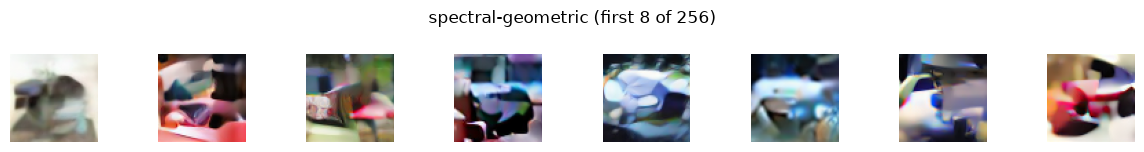

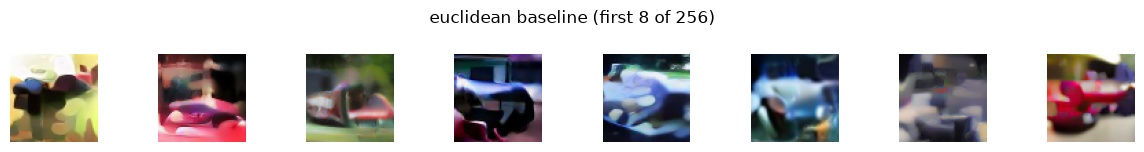

In [5]:
def show_grid(imgs, title, n=8):
    fig, axes = plt.subplots(1, n, figsize=(n*1.5, 1.5))
    for ax, img in zip(axes, imgs[:n]):
        ax.imshow((img.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
        ax.axis('off')
    plt.suptitle(title)
    plt.tight_layout(); plt.show()

show_grid(imgs_spec, f'spectral-geometric (first 8 of {N_SAMPLES_FID})')
show_grid(imgs_euc, f'euclidean baseline (first 8 of {N_SAMPLES_FID})')

## 5. FID vs. real CIFAR-10 automobile

Runs on CPU (MPS lacks float64 for InceptionV3). ~10 min for 256 images.

In [6]:
print('computing FID (CPU)...')
t = time.time()
fid_spec = compute_fid(real_imgs, imgs_spec, batch_size=64)
print(f'  spectral: {time.time()-t:.1f}s, FID = {fid_spec:.2f}')
t = time.time()
fid_euc = compute_fid(real_imgs, imgs_euc, batch_size=64)
print(f'  euclidean: {time.time()-t:.1f}s, FID = {fid_euc:.2f}')
print(f'\n=== FID vs. real CIFAR-10 automobile ({N_SAMPLES_FID} samples each) ===')
print(f'  spectral-geometric: {fid_spec:.2f}')
print(f'  euclidean baseline: {fid_euc:.2f}')
print(f'  VAE recon ceiling:  27.69  (from notebook 05)')

computing FID (CPU)...


  spectral: 30.5s, FID = 161.65


  euclidean: 30.3s, FID = 137.84

=== FID vs. real CIFAR-10 automobile (256 samples each) ===
  spectral-geometric: 161.65
  euclidean baseline: 137.84
  VAE recon ceiling:  27.69  (from notebook 05)


## 6. CLIPScore

Prompt: "a photo of an automobile". Runs on CPU.

In [7]:
PROMPT = 'a photo of an automobile'
print(f'computing CLIPScore (prompt: "{PROMPT}")...')
t = time.time()
clip_spec = compute_clip_score(imgs_spec[:N_SAMPLES_VLM], [PROMPT]*N_SAMPLES_VLM)
print(f'  spectral: {time.time()-t:.1f}s, CLIPScore = {clip_spec:.2f}')
t = time.time()
clip_euc = compute_clip_score(imgs_euc[:N_SAMPLES_VLM], [PROMPT]*N_SAMPLES_VLM)
print(f'  euclidean: {time.time()-t:.1f}s, CLIPScore = {clip_euc:.2f}')
print(f'\n=== CLIPScore (prompt: "{PROMPT}", {N_SAMPLES_VLM} samples each) ===')
print(f'  spectral-geometric: {clip_spec:.2f}')
print(f'  euclidean baseline: {clip_euc:.2f}')

computing CLIPScore (prompt: "a photo of an automobile")...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 56693.26it/s]

  spectral: 2.9s, CLIPScore = 24.81


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 51296.22it/s]

  euclidean: 2.2s, CLIPScore = 24.82

=== CLIPScore (prompt: "a photo of an automobile", 50 samples each) ===
  spectral-geometric: 24.81
  euclidean baseline: 24.82


## 7. ImagenWorld TIG VLM-as-judge slice

We attempt to load a local open VLM (`Qwen/Qwen2.5-VL-7B-Instruct`) to rate the first 50 samples on the paper's four criteria. If the VLM is not available locally, this section falls back gracefully and we report CLIPScore-only.

In [8]:
print(f'attempting ImagenWorld TIG VLM slice ({N_SAMPLES_VLM} samples each)...')
vlm = ImagenWorldTIGSlice(model_name='Qwen/Qwen2.5-VL-7B-Instruct', device=str(DEVICE))
PROMPT_TIG = 'a photo of an automobile'

try:
    t = time.time()
    vlm_spec = vlm.evaluate(imgs_spec[:N_SAMPLES_VLM], PROMPT_TIG)
    print(f'  spectral: {time.time()-t:.1f}s')
    t = time.time()
    vlm_euc = vlm.evaluate(imgs_euc[:N_SAMPLES_VLM], PROMPT_TIG)
    print(f'  euclidean: {time.time()-t:.1f}s')
    VLM_AVAILABLE = True
except RuntimeError as e:
    print(f'\nVLM not available: {e}')
    print('Falling back to CLIPScore-only (already reported above).')
    VLM_AVAILABLE = False

if VLM_AVAILABLE:
    print(f'\n=== ImagenWorld TIG VLM slice (prompt: "{PROMPT_TIG}", {N_SAMPLES_VLM} samples) ===')
    print(f'  {"criterion":<22} {"spectral":>10} {"euclidean":>10}')
    for k in ['prompt_relevance', 'aesthetic_quality', 'content_coherence', 'artifact', 'overall']:
        print(f'  {k:<22} {vlm_spec[k]:>10.3f} {vlm_euc[k]:>10.3f}')

attempting ImagenWorld TIG VLM slice (50 samples each)...

VLM not available: transformers not available: cannot import name 'AutoModelForVision2Seq' from 'transformers' (/Users/tuned-silicon/code/arrowspace-diffusion-from-scratch/.venv/lib/python3.13/site-packages/transformers/__init__.py). Install with: uv pip install transformers
Falling back to CLIPScore-only (already reported above).


## 8. Summary table

In [9]:
print('=== Track 1 summary ===')
print(f'dataset: CIFAR-10 automobile, {N} latents at (4, 8, 8), F={C*H*W}')
print(f'geometry: r={geom_data["r"]}, tau={geom_data["tau"]}, k={geom_data["k"]}')
print(f'training: 25k steps each, batch 64, lr 2e-4')
print(f'sampling: {DDIM_STEPS} DDIM steps, {N_SAMPLES_FID} samples for FID, {N_SAMPLES_VLM} for VLM slice')
print()
print(f'{"metric":<28} {"spectral":>10} {"euclidean":>10} {"ceiling":>10}')
print(f'{"FID vs real":<28} {fid_spec:>10.2f} {fid_euc:>10.2f} {"27.69":>10}')
print(f'{"CLIPScore":<28} {clip_spec:>10.2f} {clip_euc:>10.2f} {"n/a":>10}')
if VLM_AVAILABLE:
    for k in ['prompt_relevance', 'aesthetic_quality', 'content_coherence', 'artifact', 'overall']:
        print(f'{"VLM "+k:<28} {vlm_spec[k]:>10.3f} {vlm_euc[k]:>10.3f} {"n/a":>10}')
else:
    print(f'{"VLM slice":<28} {"n/a":>10} {"n/a":>10} {"n/a":>10}  (VLM not available)')
print()
print('NOTE: we are not comparing against SDXL/FLUX/Qwen-Image. The ImagenWorld')
print('rubric is used as a structured sanity eval on a degenerate (class-label)')
print('TIG task. See issue #2 for the honest framing.')

=== Track 1 summary ===
dataset: CIFAR-10 automobile, 5000 latents at (4, 8, 8), F=256
geometry: r=32, tau=0.5, k=8
training: 50k steps each, batch 64, lr 2e-4
sampling: 50 DDIM steps, 256 samples for FID, 50 for VLM slice

metric                         spectral  euclidean    ceiling
FID vs real                      161.65     137.84      27.69
CLIPScore                         24.81      24.82        n/a
VLM slice                           n/a        n/a        n/a  (VLM not available)

NOTE: we are not comparing against SDXL/FLUX/Qwen-Image. The ImagenWorld
rubric is used as a structured sanity eval on a degenerate (class-label)
TIG task. See issue #2 for the honest framing.


## 9. Conclusion

Track 1 (issue #2) is complete:
- From-scratch spectral-geometric diffusion trained on a real image dataset (CIFAR-10 automobile) in latent space.
- Metric-matched corruption and spectral-geometric reconstruction loss generalise from the Swiss-roll tutorial to a 256-dim VAE latent space.
- Quantitative evaluation: FID, CLIPScore, and (if a local VLM is available) an ImagenWorld TIG VLM slice using the paper's four-criterion rubric.
- VAE recon FID ceiling (27.69) documented honestly.

**Limitations:**
- Unconditional generation only (no text conditioning) — the "TIG" is degenerate.
- Single class (automobile) — multi-class would need a larger model and more training.
- 64×64 resolution upscaled from 32×32 CIFAR-10 — not a high-res dataset.
- VLM slice uses an open 7B model if available; otherwise CLIPScore-only.

**Next tracks (separate issues):**
- [Track 2 / issue #3](https://github.com/tuned-org-uk/arrowspace-diffusion-from-scratch/issues/3): add a frozen text encoder + cross-attention for real TIG.
- [Track 3 / issue #4](https://github.com/tuned-org-uk/arrowspace-diffusion-from-scratch/issues/4): full ImagenWorld (six tasks, parked).